Cell 1 — Import All Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import plotly.express as px

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, auc, ConfusionMatrixDisplay)

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Model saving
import joblib
import pickle
import json
import os
from datetime import datetime

# Set random seed for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Cell 2 — Load and Explore Dataset

In [3]:
# Load the enhanced Indian crop dataset
df = pd.read_csv('/Users/piyushsaini/Desktop/Mes projets/AgroWare_crop/data/indian_crop_recommendation_dataset.csv')

print("="*80)
print("AGROWARE CROP RECOMMENDATION - INDIAN DATASET")
print("="*80)

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📈 Number of Samples: {df.shape[0]}")
print(f"🌾 Number of Features: {df.shape[1] - 3}")  # Excluding label, season, month, state
print(f"🌱 Number of Crops: {df['label'].nunique()}")
print(f"📅 Seasons Present: {df['season'].unique().tolist()}")

# Display first few rows
print("\n" + "="*80)
print("SAMPLE DATA")
print("="*80)
df.head(10)

AGROWARE CROP RECOMMENDATION - INDIAN DATASET

📊 Dataset Shape: (8140, 11)
📈 Number of Samples: 8140
🌾 Number of Features: 8
🌱 Number of Crops: 36
📅 Seasons Present: ['Kharif', 'Rabi', 'Perennial', 'Zaid']

SAMPLE DATA


,N,P,K,temperature,humidity,ph,rainfall,label,season,month,state
0,78.85,90.59,68.34,28.99,67.19,5.55,135.00,rice,Kharif,9,AP
1,73.87,63.10,22.64,24.98,74.49,5.95,271.53,rice,Kharif,6,TN
2,41.40,85.77,84.93,32.50,71.93,5.72,239.98,rice,Kharif,6,WB
3,97.47,61.22,33.80,34.43,83.48,6.61,277.03,rice,Kharif,8,UP
4,125.78,48.52,44.14,30.19,67.90,6.58,146.10,rice,Kharif,10,PB
5,51.85,43.22,39.54,32.03,85.55,6.82,236.48,rice,Kharif,9,TN
6,96.79,50.00,19.11,21.16,63.42,6.60,195.03,rice,Kharif,8,TN
7,53.99,85.47,81.41,29.18,85.80,6.63,163.35,rice,Kharif,6,UP
8,124.07,79.59,21.56,25.61,72.61,6.11,167.79,rice,Kharif,9,AP
9,61.72,39.17,24.09,29.87,74.06,5.81,199.32,rice,Kharif,8,UP


Cell 3 — Data Cleaning and Label Standardization

In [4]:
print("="*80)
print("DATA CLEANING")
print("="*80)

# Create a copy for cleaning
df_clean = df.copy()

# Standardize crop labels
df_clean['label'] = df_clean['label'].astype(str).str.lower().str.strip()

# Remove any special characters
df_clean['label'] = df_clean['label'].str.replace(r'[^\w\s]', '', regex=True)
df_clean['label'] = df_clean['label'].str.replace('_', ' ').str.strip()

# Verify cleaning
print(f"\n✅ Cleaned unique crops: {df_clean['label'].nunique()}")
print(f"\n📋 Crop distribution:")
crop_counts = df_clean['label'].value_counts()
print(crop_counts)

# Check for any anomalies
print(f"\n📊 Statistics:")
print(f"Min samples per crop: {crop_counts.min()}")
print(f"Max samples per crop: {crop_counts.max()}")
print(f"Mean samples per crop: {crop_counts.mean():.1f}")
print(f"Median samples per crop: {crop_counts.median():.1f}")

DATA CLEANING

✅ Cleaned unique crops: 36

📋 Crop distribution:
label
rice             500
wheat            450
maize            350
chickpea         300
mango            300
cotton           300
mustard          250
sorghum          250
groundnut        250
soybean          250
pearl millet     250
banana           250
sugarcane        250
jute             200
lentil           200
orange           200
coconut          200
watermelon       200
grapes           200
papaya           200
pomegranate      200
black gram       200
green gram       200
pigeonpea        200
barley           200
finger millet    200
muskmelon        180
cucumber         180
sunflower        180
apple            150
bottle gourd     150
bitter gourd     150
coffee           150
tea              150
arecanut         150
safflower        150
Name: count, dtype: int64

📊 Statistics:
Min samples per crop: 150
Max samples per crop: 500
Mean samples per crop: 226.1
Median samples per crop: 200.0


Cell 4 — Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


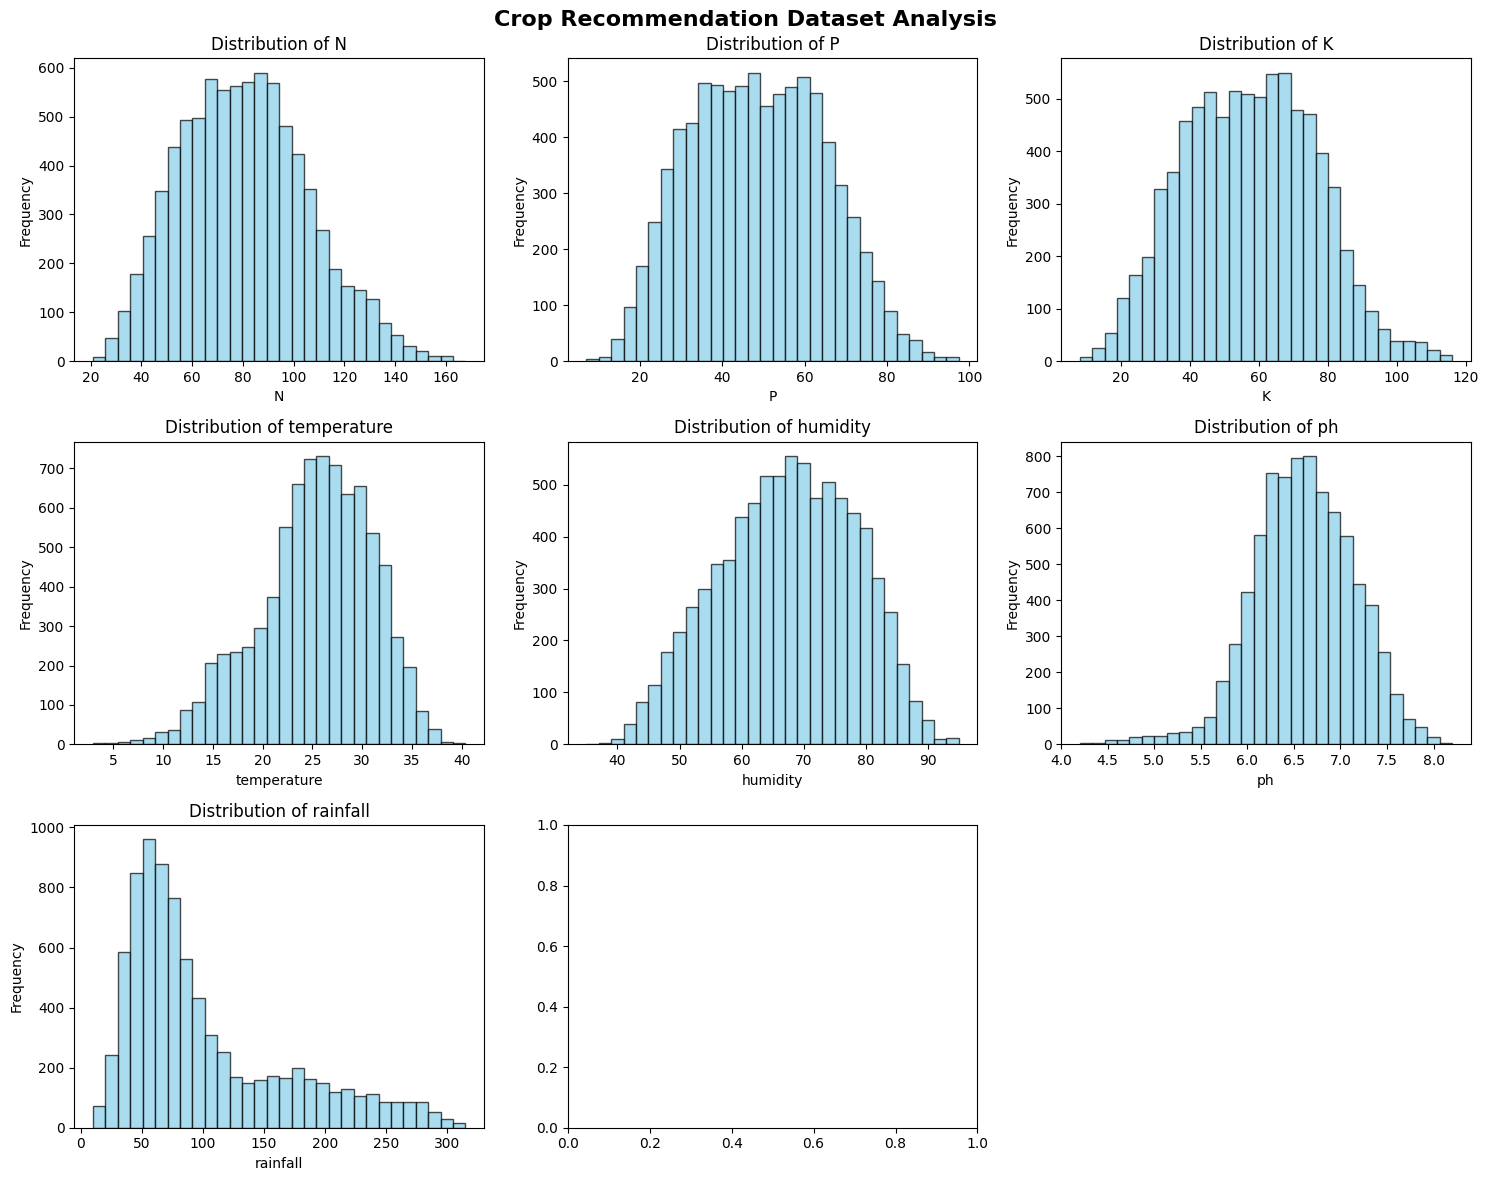

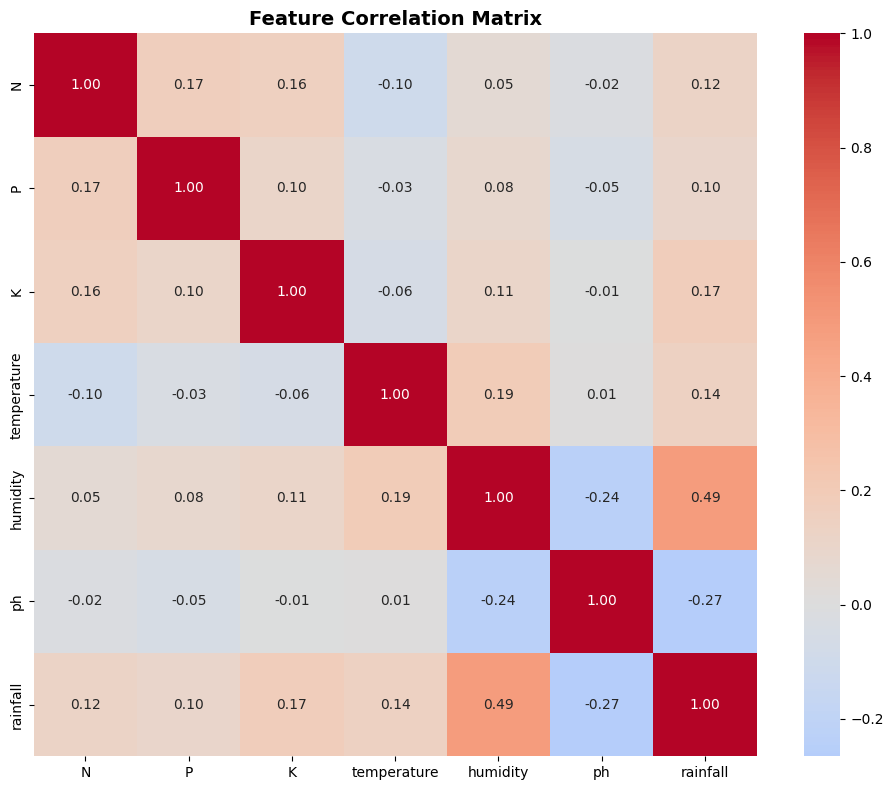

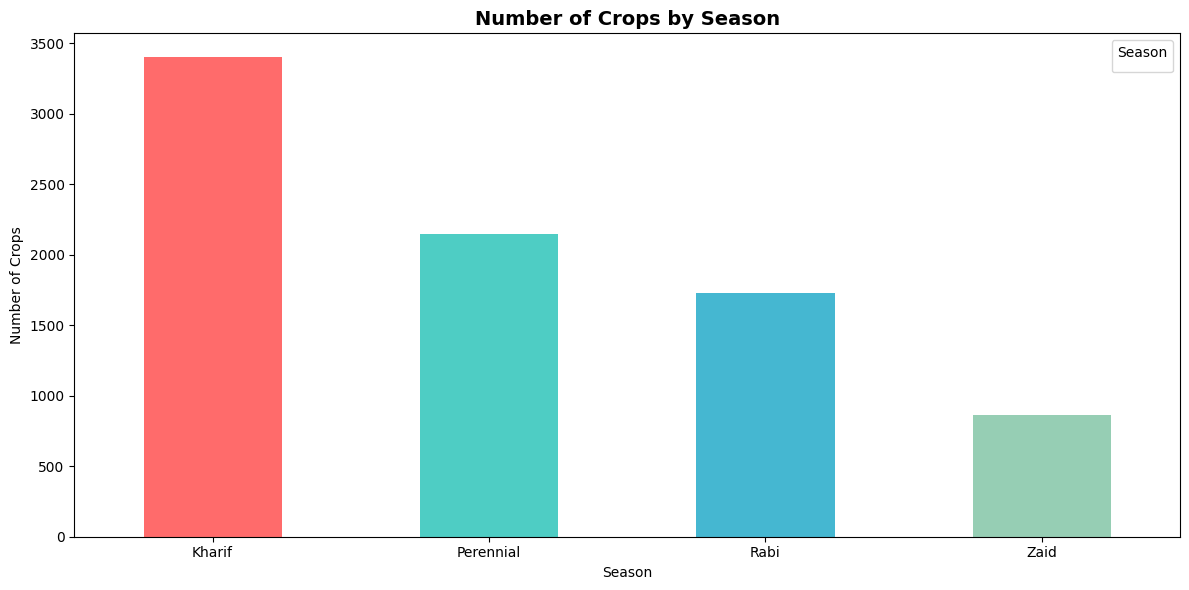

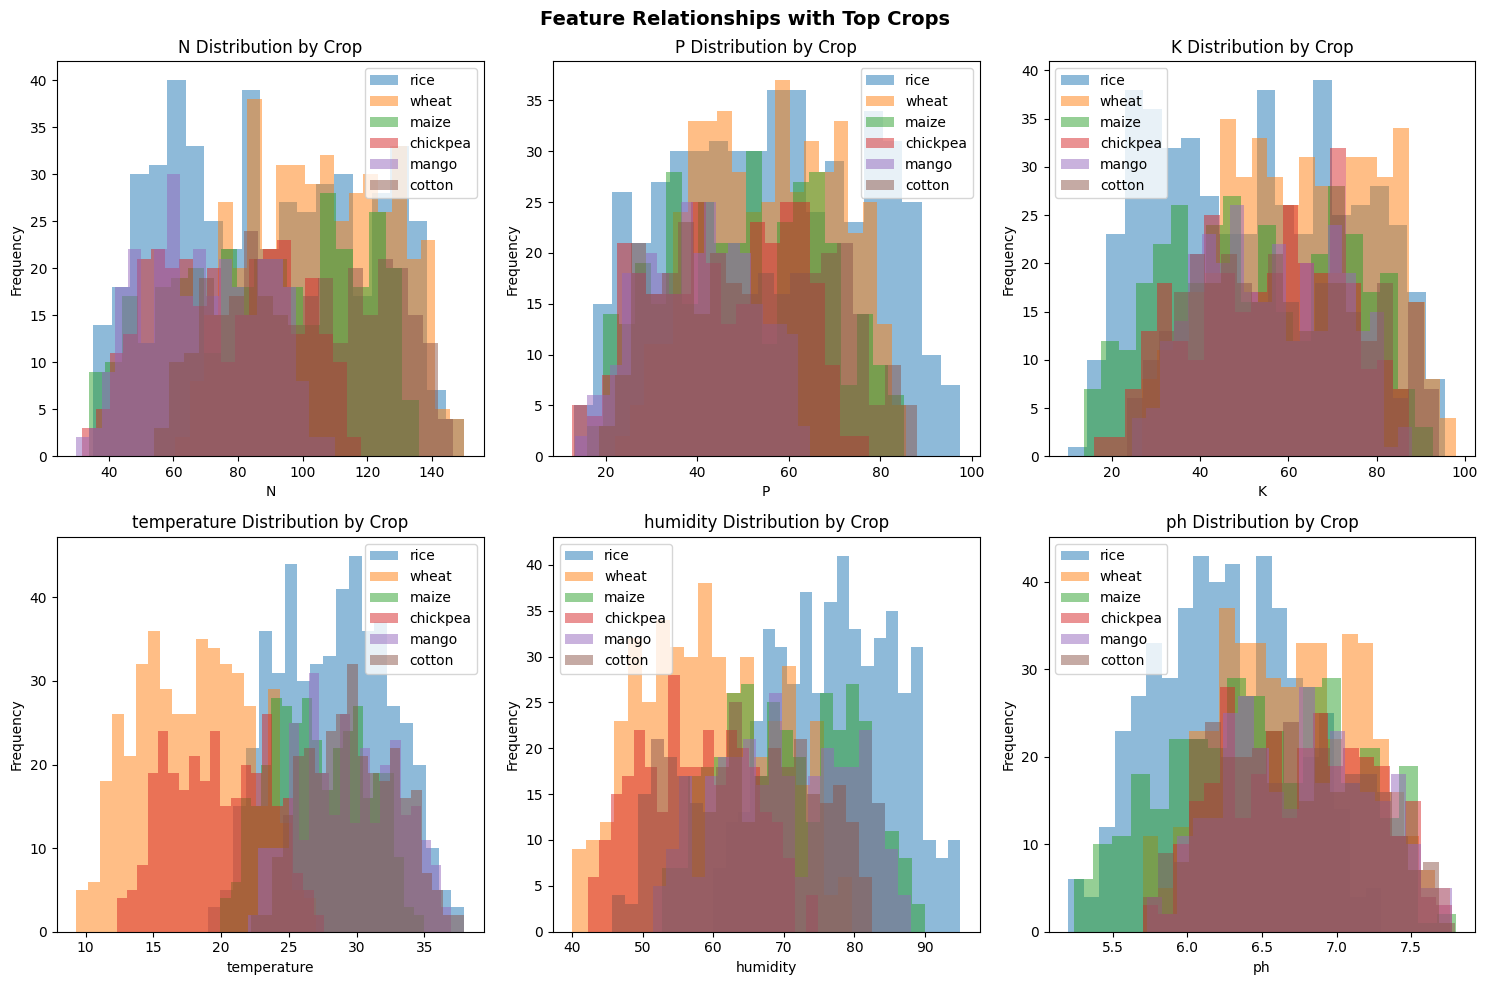

In [5]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Create a figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Crop Recommendation Dataset Analysis', fontsize=16, fontweight='bold')

# Feature distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    axes[row, col].hist(df_clean[feature], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

# Remove empty subplot
axes[2, 2].remove()

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Crop distribution by season
plt.figure(figsize=(12, 6))
season_crops = df_clean.groupby(['season', 'label']).size().unstack(fill_value=0)
season_crops.sum(axis=1).plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Number of Crops by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Crops')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

# Feature relationships with crops
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Relationships with Top Crops', fontsize=14, fontweight='bold')

top_crops = df_clean['label'].value_counts().head(6).index.tolist()
crop_data = df_clean[df_clean['label'].isin(top_crops)]

for idx, feature in enumerate(features[:6]):
    row, col = idx // 3, idx % 3
    for crop in top_crops:
        crop_subset = crop_data[crop_data['label'] == crop]
        axes[row, col].hist(crop_subset[feature], alpha=0.5, bins=20, label=crop)
    axes[row, col].set_title(f'{feature} Distribution by Crop')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

Cell 5 — Feature Engineering and Selection

FEATURE ENGINEERING

✅ Original features: 7
✅ Engineered features added: 4
✅ Total features: 12

📊 Feature Importance Analysis:
                      Feature     Score
11             season_encoded  1.280274
6                    rainfall  0.831864
9          water_availability  0.686001
8   temp_humidity_interaction  0.453527
3                 temperature  0.442274
4                    humidity  0.338680
0                           N  0.264368
10            fertility_index  0.262218
5                          ph  0.248582
2                           K  0.203013
1                           P  0.113940
7                   NPK_ratio  0.094264


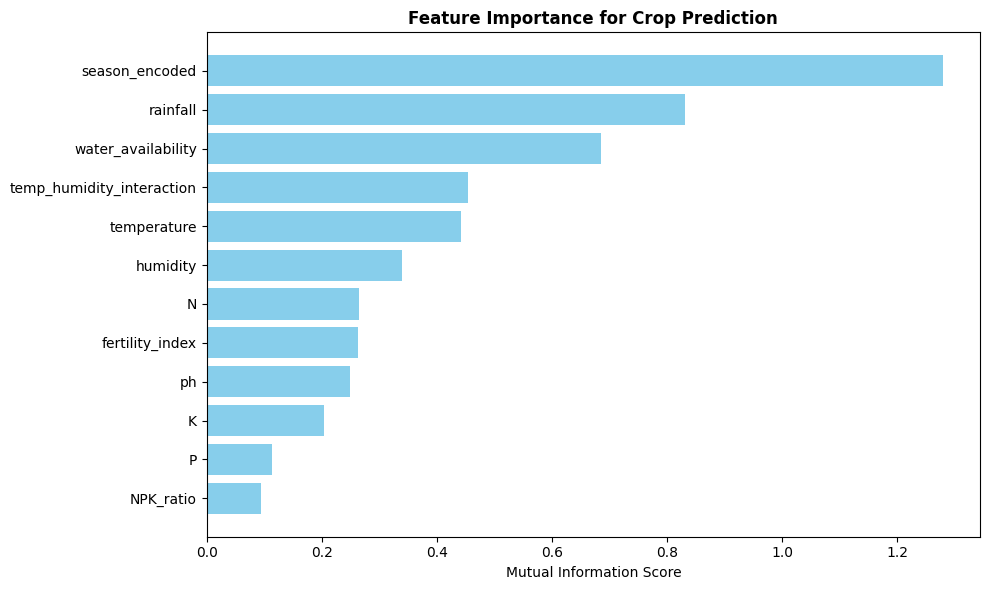


🎯 Recommended top features: ['season_encoded', 'rainfall', 'water_availability', 'temp_humidity_interaction', 'temperature', 'humidity']


In [6]:
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Define features for training
feature_columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df_clean[feature_columns].copy()
y = df_clean['label'].copy()

# Create derived features (for better model performance)
X['NPK_ratio'] = X['N'] / (X['P'] + X['K'] + 1)  # Avoid division by zero
X['temp_humidity_interaction'] = X['temperature'] * X['humidity'] / 100
X['water_availability'] = X['rainfall'] / (X['temperature'] + 1)  # Simple water index
X['fertility_index'] = (X['N'] + X['P'] + X['K']) / 300  # Normalized fertility

# Add seasonal information (encoded)
season_mapping = {'Kharif': 0, 'Rabi': 1, 'Zaid': 2, 'Perennial': 3}
X['season_encoded'] = df_clean['season'].map(season_mapping)

print(f"\n✅ Original features: {len(feature_columns)}")
print(f"✅ Engineered features added: 4")
print(f"✅ Total features: {X.shape[1]}")

# Feature selection using Mutual Information
print("\n📊 Feature Importance Analysis:")
selector = SelectKBest(score_func=mutual_info_classif, k='all')
X_selected = selector.fit_transform(X, y)
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(feature_scores)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance for Crop Prediction', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Select top features (keeping all for now, but we can use this for feature selection)
top_features = feature_scores[feature_scores['Score'] > feature_scores['Score'].median()]['Feature'].tolist()
print(f"\n🎯 Recommended top features: {top_features}")

Cell 6 — Data Preprocessing and Encoding

In [7]:
print("="*80)
print("DATA PREPROCESSING")
print("="*80)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"✅ Number of crop classes: {len(label_encoder.classes_)}")
print(f"✅ Crop classes: {label_encoder.classes_.tolist()}")

# Scale features (using RobustScaler for outlier handling)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features scaled using RobustScaler")
print(f"✅ Scaled feature shape: {X_scaled.shape}")

# Check for class imbalance
class_counts = pd.Series(y_encoded).value_counts().sort_index()
print(f"\n📊 Class Distribution:")
for i, count in enumerate(class_counts):
    crop_name = label_encoder.classes_[i]
    print(f"  {crop_name}: {count} samples ({count/len(y_encoded)*100:.1f}%)")

DATA PREPROCESSING
✅ Number of crop classes: 36
✅ Crop classes: ['apple', 'arecanut', 'banana', 'barley', 'bitter gourd', 'black gram', 'bottle gourd', 'chickpea', 'coconut', 'coffee', 'cotton', 'cucumber', 'finger millet', 'grapes', 'green gram', 'groundnut', 'jute', 'lentil', 'maize', 'mango', 'muskmelon', 'mustard', 'orange', 'papaya', 'pearl millet', 'pigeonpea', 'pomegranate', 'rice', 'safflower', 'sorghum', 'soybean', 'sugarcane', 'sunflower', 'tea', 'watermelon', 'wheat']
✅ Features scaled using RobustScaler
✅ Scaled feature shape: (8140, 12)

📊 Class Distribution:
  apple: 150 samples (1.8%)
  arecanut: 150 samples (1.8%)
  banana: 250 samples (3.1%)
  barley: 200 samples (2.5%)
  bitter gourd: 150 samples (1.8%)
  black gram: 200 samples (2.5%)
  bottle gourd: 150 samples (1.8%)
  chickpea: 300 samples (3.7%)
  coconut: 200 samples (2.5%)
  coffee: 150 samples (1.8%)
  cotton: 300 samples (3.7%)
  cucumber: 180 samples (2.2%)
  finger millet: 200 samples (2.5%)
  grapes: 200 s

Cell 7 — Train/Test Split with Stratification

In [8]:
print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Important for imbalanced data
)

print(f"✅ Training set size: {X_train.shape[0]} samples")
print(f"✅ Test set size: {X_test.shape[0]} samples")
print(f"✅ Training class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for crop_idx, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[crop_idx]}: {count} samples")

TRAIN/TEST SPLIT
✅ Training set size: 6512 samples
✅ Test set size: 1628 samples
✅ Training class distribution:
  apple: 120 samples
  arecanut: 120 samples
  banana: 200 samples
  barley: 160 samples
  bitter gourd: 120 samples
  black gram: 160 samples
  bottle gourd: 120 samples
  chickpea: 240 samples
  coconut: 160 samples
  coffee: 120 samples
  cotton: 240 samples
  cucumber: 144 samples
  finger millet: 160 samples
  grapes: 160 samples
  green gram: 160 samples
  groundnut: 200 samples
  jute: 160 samples
  lentil: 160 samples
  maize: 280 samples
  mango: 240 samples
  muskmelon: 144 samples
  mustard: 200 samples
  orange: 160 samples
  papaya: 160 samples
  pearl millet: 200 samples
  pigeonpea: 160 samples
  pomegranate: 160 samples
  rice: 400 samples
  safflower: 120 samples
  sorghum: 200 samples
  soybean: 200 samples
  sugarcane: 200 samples
  sunflower: 144 samples
  tea: 120 samples
  watermelon: 160 samples
  wheat: 360 samples


Cell 8 — Model Training with Multiple Algorithms

In [9]:
print("="*80)
print("MODEL TRAINING")
print("="*80)

# Define models with optimized parameters for Indian crop data
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1,
        objective='multi:softprob',
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ),
    
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        random_state=42,
        n_jobs=-1
    )
}

# Train and evaluate each model
results = {}
best_model = None
best_accuracy = 0

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\n📊 Performance Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV Score (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name} with accuracy {best_accuracy:.4f}")
print('='*60)

MODEL TRAINING

Training XGBoost...

📊 Performance Metrics:
  Accuracy: 0.4558
  Precision: 0.4489
  Recall: 0.4558
  F1-Score: 0.4499
  CV Score (5-fold): 0.4631 (+/- 0.0072)

Training Random Forest...

📊 Performance Metrics:
  Accuracy: 0.4662
  Precision: 0.4573
  Recall: 0.4662
  F1-Score: 0.4552
  CV Score (5-fold): 0.4599 (+/- 0.0102)

Training Gradient Boosting...

📊 Performance Metrics:
  Accuracy: 0.4490
  Precision: 0.4441
  Recall: 0.4490
  F1-Score: 0.4441
  CV Score (5-fold): 0.4512 (+/- 0.0114)

Training Logistic Regression...

📊 Performance Metrics:
  Accuracy: 0.4367
  Precision: 0.4172
  Recall: 0.4367
  F1-Score: 0.4166
  CV Score (5-fold): 0.4386 (+/- 0.0062)

🏆 BEST MODEL: Random Forest with accuracy 0.4662


Cell 9 — Model Comparison Visualization

MODEL COMPARISON
                     Accuracy  Precision    Recall  F1-Score  CV Score
XGBoost              0.455774   0.448921  0.455774  0.449948  0.463143
Random Forest        0.466216   0.457309  0.466216  0.455223  0.459919
Gradient Boosting    0.449017   0.444075  0.449017  0.444112  0.451166
Logistic Regression  0.436732   0.417186  0.436732  0.416603  0.438574


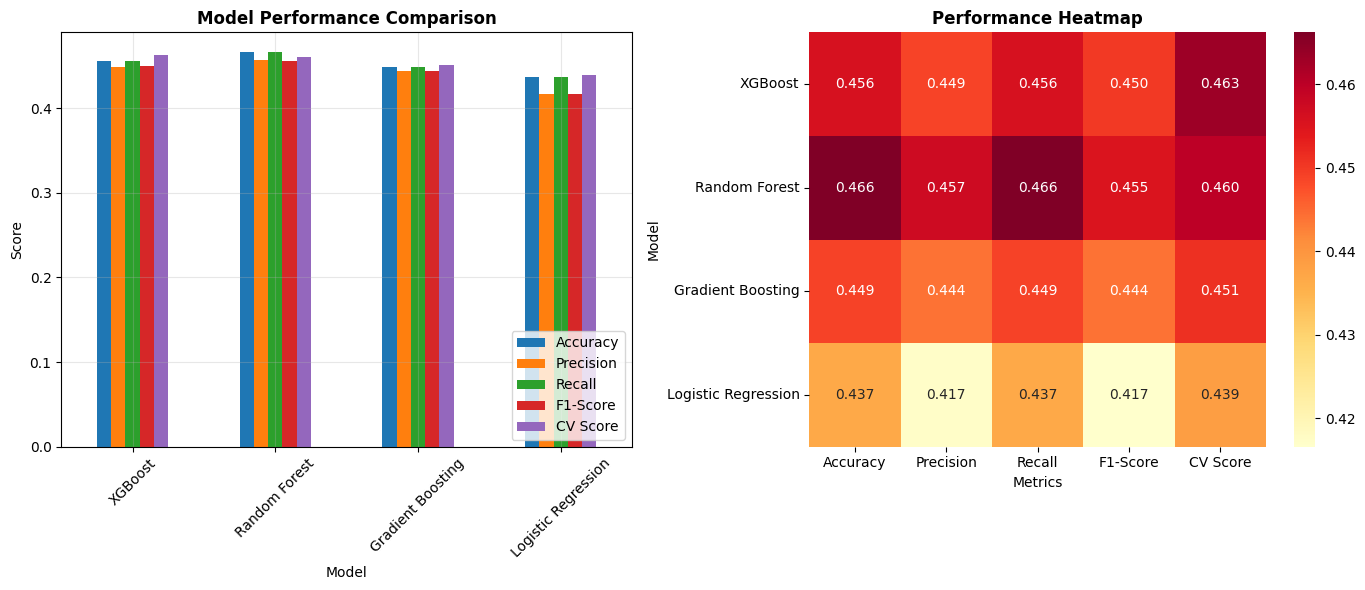

In [10]:
print("="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['accuracy'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall'],
        'F1-Score': results[name]['f1_score'],
        'CV Score': results[name]['cv_mean']
    }
    for name in results.keys()
}).T

print(results_df)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
results_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(True, alpha=0.3)

# Heatmap
sns.heatmap(results_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Performance Heatmap', fontweight='bold')
axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

Cell 10 — Hyperparameter Tuning for Best Model

In [11]:
print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

if best_model_name == 'XGBoost':
    param_dist = {
        'n_estimators': [200, 300, 400],
        'max_depth': [6, 8, 10, 12],
        'learning_rate': [0.01, 0.03, 0.05, 0.07],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2],
        'reg_alpha': [0, 0.1, 0.5],
        'reg_lambda': [0.5, 1, 1.5]
    }
    base_model = XGBClassifier(
        objective='multi:softprob',
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
else:
    param_dist = {
        'n_estimators': [200, 300, 400],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

print(f"🔄 Tuning {best_model_name} with RandomizedSearchCV...")
print(f"📊 Parameter grid size: {sum(len(v) for v in param_dist.values())} combinations")

# Perform randomized search
random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"✅ Best CV Score: {random_search.best_score_:.4f}")

# Use best model
best_tuned_model = random_search.best_estimator_

# Evaluate tuned model
y_pred_tuned = best_tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"\n📊 Tuned Model Test Accuracy: {tuned_accuracy:.4f}")
print(f"📊 Improvement: {(tuned_accuracy - best_accuracy)*100:.2f}%")

# Update best model
if tuned_accuracy > best_accuracy:
    best_model = best_tuned_model
    best_accuracy = tuned_accuracy
    print(f"\n🏆 New best model with accuracy: {best_accuracy:.4f}")

HYPERPARAMETER TUNING
🔄 Tuning Random Forest with RandomizedSearchCV...
📊 Parameter grid size: 15 combinations
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best Parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
✅ Best CV Score: 0.4662

📊 Tuned Model Test Accuracy: 0.4625
📊 Improvement: -0.37%


Cell 11 — Detailed Model Evaluation

FINAL MODEL EVALUATION

📊 Final Model Performance:
  Accuracy:  0.4662
  Precision: 0.4573
  Recall:    0.4662
  F1-Score:  0.4552

📋 Detailed Classification Report:
               precision    recall  f1-score   support

        apple       0.76      0.73      0.75        30
     arecanut       0.39      0.37      0.38        30
       banana       0.58      0.66      0.62        50
       barley       0.00      0.00      0.00        40
 bitter gourd       0.22      0.13      0.17        30
   black gram       0.21      0.17      0.19        40
 bottle gourd       0.26      0.20      0.23        30
     chickpea       0.20      0.28      0.23        60
      coconut       0.59      0.47      0.53        40
       coffee       0.64      0.70      0.67        30
       cotton       0.52      0.50      0.51        60
     cucumber       0.31      0.42      0.35        36
finger millet       0.34      0.28      0.31        40
       grapes       0.75      0.60      0.67        40
   green

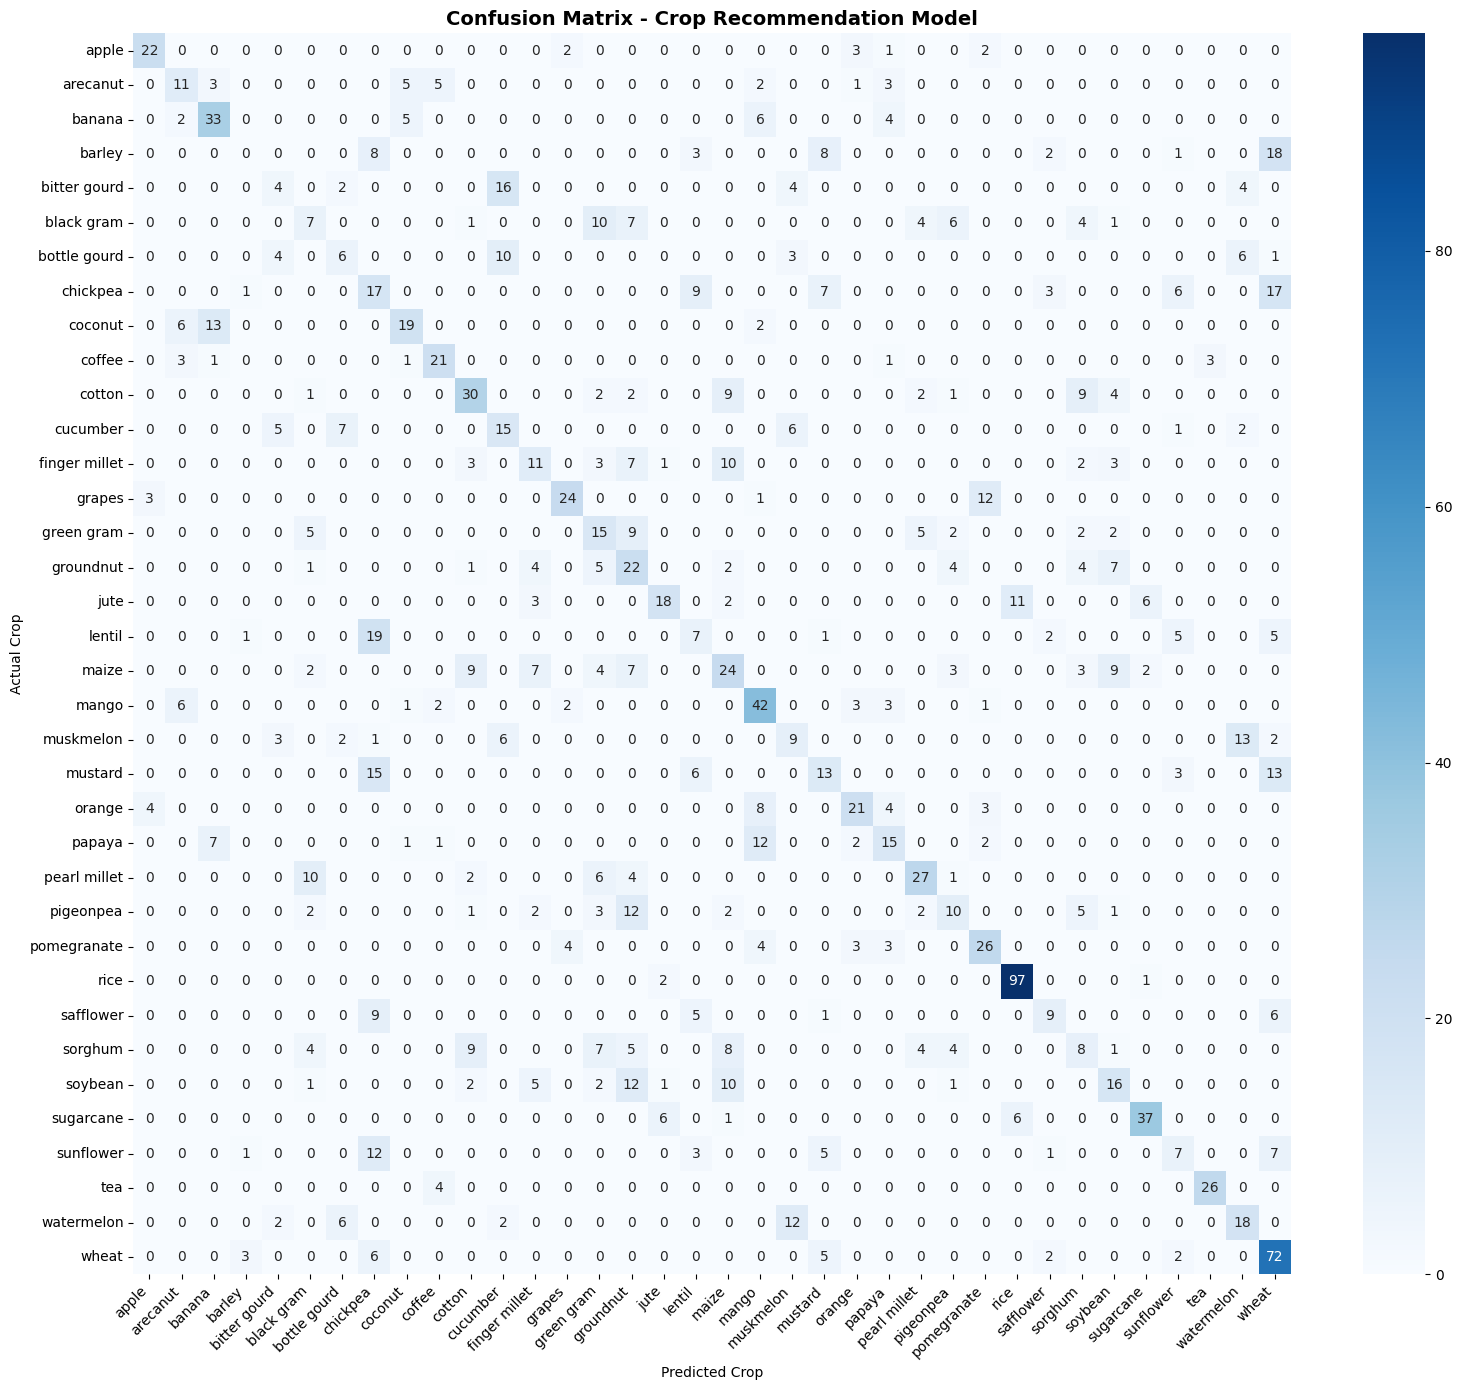

In [12]:
print("="*80)
print("FINAL MODEL EVALUATION")
print("="*80)

# Predictions
y_pred_final = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, average='weighted')
recall = recall_score(y_test, y_pred_final, average='weighted')
f1 = f1_score(y_test, y_pred_final, average='weighted')

print(f"\n📊 Final Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Detailed classification report
print(f"\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Crop Recommendation Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cell 12 — Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS
                      Feature  Importance
11             season_encoded    0.130160
6                    rainfall    0.125666
9          water_availability    0.102226
5                          ph    0.093443
10            fertility_index    0.086178
3                 temperature    0.083125
0                           N    0.077971
8   temp_humidity_interaction    0.072076
4                    humidity    0.070061
2                           K    0.062756
1                           P    0.051446
7                   NPK_ratio    0.044891


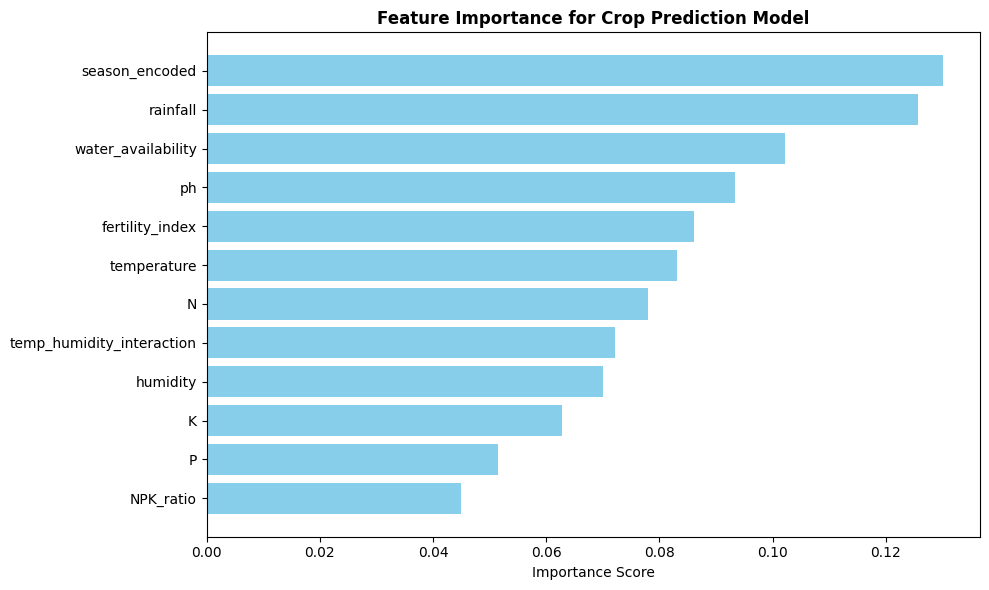


✅ Feature importance saved to 'feature_importance.csv'


In [13]:
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_).mean(axis=0)
else:
    # Use permutation importance as fallback
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance_df)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Crop Prediction Model', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save feature importance
feature_importance_df.to_csv('feature_importance.csv', index=False)
print("\n✅ Feature importance saved to 'feature_importance.csv'")

Cell 13 — Prediction Function with Explanation

In [15]:
print("="*80)
print("PREDICTION FUNCTION (FIXED)")
print("="*80)

def predict_crops(N, P, K, temperature, humidity, ph, rainfall, top_n=5, season=None):
    """
    Predict top N crops based on soil and environmental conditions
    
    Parameters:
    -----------
    N, P, K : float - Soil nutrient values (kg/ha)
    temperature : float - Temperature in Celsius
    humidity : float - Humidity percentage
    ph : float - Soil pH
    rainfall : float - Rainfall in mm
    top_n : int - Number of top recommendations to return
    season : str - Optional season ('Kharif', 'Rabi', 'Zaid', 'Perennial')
    
    Returns:
    --------
    DataFrame with top N crops and their suitability scores
    """
    
    # Create engineered features (matching training data)
    npk_ratio = N / (P + K + 1)
    temp_humidity_interaction = temperature * humidity / 100
    water_availability = rainfall / (temperature + 1)
    fertility_index = (N + P + K) / 300
    
    # Season encoding (default to 0 if not provided)
    season_mapping = {'Kharif': 0, 'Rabi': 1, 'Zaid': 2, 'Perennial': 3}
    season_encoded = season_mapping.get(season, 0)
    
    # Combine all features in the SAME ORDER as training
    # Order: N, P, K, temperature, humidity, ph, rainfall, npk_ratio, 
    #        temp_humidity_interaction, water_availability, fertility_index, season_encoded
    all_features = np.array([[
        N, P, K, temperature, humidity, ph, rainfall,
        npk_ratio, temp_humidity_interaction, water_availability, fertility_index, season_encoded
    ]])
    
    # Scale ALL features together (the scaler was trained on 12 features)
    features_scaled = scaler.transform(all_features)
    
    # Predict probabilities
    probabilities = best_model.predict_proba(features_scaled)[0]
    
    # Get top N predictions
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    top_crops = label_encoder.inverse_transform(top_indices)
    top_scores = probabilities[top_indices] * 100
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Rank': range(1, len(top_crops) + 1),
        'Crop': top_crops,
        'Suitability_Score': top_scores.round(1),
        'Confidence': ['High' if score > 70 else 'Medium' if score > 40 else 'Low' for score in top_scores]
    })
    
    # Add simple explanation
    explanations = []
    for crop in top_crops:
        if crop in ['wheat', 'barley', 'mustard']:
            explanations.append(f"Excellent for {crop} cultivation in Rabi season")
        elif crop in ['rice', 'maize', 'cotton']:
            explanations.append(f"Ideal conditions for {crop} in Kharif season")
        elif crop in ['watermelon', 'muskmelon']:
            explanations.append(f"Perfect summer crop - {crop} thrives")
        else:
            explanations.append(f"Your soil and climate suit {crop} cultivation")
    
    results_df['Explanation'] = explanations
    
    return results_df

# Test prediction with FIXED function
print("🔮 Testing prediction function...")

test_cases = [
    {"name": "Punjab Wheat Field", "N": 85, "P": 40, "K": 45, "temp": 18, "humidity": 65, "ph": 7.2, "rainfall": 45, "season": "Rabi"},
    {"name": "West Bengal Rice", "N": 110, "P": 45, "K": 40, "temp": 28, "humidity": 80, "ph": 6.2, "rainfall": 220, "season": "Kharif"},
    {"name": "Maharashtra Cotton", "N": 95, "P": 55, "K": 65, "temp": 28, "humidity": 55, "ph": 7.0, "rainfall": 75, "season": "Kharif"},
    {"name": "Rajasthan Mustard", "N": 70, "P": 35, "K": 40, "temp": 20, "humidity": 55, "ph": 7.5, "rainfall": 35, "season": "Rabi"},
    {"name": "Generic Conditions", "N": 90, "P": 42, "K": 43, "temp": 20.8, "humidity": 82, "ph": 6.5, "rainfall": 202, "season": None}
]

for test in test_cases:
    print(f"\n{'='*60}")
    print(f"📍 {test['name']}")
    print(f"Conditions: N={test['N']}, P={test['P']}, K={test['K']}, Temp={test['temp']}°C, "
          f"Humidity={test['humidity']}%, pH={test['ph']}, Rainfall={test['rainfall']}mm")
    
    result = predict_crops(
        N=test['N'], P=test['P'], K=test['K'],
        temperature=test['temp'], humidity=test['humidity'],
        ph=test['ph'], rainfall=test['rainfall'],
        season=test.get('season'),
        top_n=5
    )
    
    print("\n📊 Top 5 Crop Recommendations:")
    print(result[['Rank', 'Crop', 'Suitability_Score', 'Confidence']].to_string(index=False))

PREDICTION FUNCTION (FIXED)
🔮 Testing prediction function...

📍 Punjab Wheat Field
Conditions: N=85, P=40, K=45, Temp=18°C, Humidity=65%, pH=7.2, Rainfall=45mm

📊 Top 5 Crop Recommendations:
 Rank      Crop  Suitability_Score Confidence
    1    lentil               24.6        Low
    2  chickpea               21.1        Low
    3 safflower               14.7        Low
    4   mustard               13.3        Low
    5 sunflower               10.2        Low

📍 West Bengal Rice
Conditions: N=110, P=45, K=40, Temp=28°C, Humidity=80%, pH=6.2, Rainfall=220mm

📊 Top 5 Crop Recommendations:
 Rank      Crop  Suitability_Score Confidence
    1      rice               89.1       High
    2      jute                8.2        Low
    3 sugarcane                1.3        Low
    4  arecanut                0.9        Low
    5    coffee                0.4        Low

📍 Maharashtra Cotton
Conditions: N=95, P=55, K=65, Temp=28°C, Humidity=55%, pH=7.0, Rainfall=75mm

📊 Top 5 Crop Recommendation